# Scenario 2: Website Analytics Debug
Scenario: The marketing team reports that the user engagement metrics code is showing impossible results (bounce rates over 100%, negative session times).

Problematic Code:

def analyze_user_engagement(logs_df):
    metrics = {
        'bounce_rate': logs_df.groupby('session_id')['page_views'].apply(
            lambda x: x == 1).mean(),
        'avg_session_time': logs_df.groupby('session_id')['duration'].sum(),
        'pages_per_session': logs_df.groupby('session_id')['page_views'].mean()
    }
    
    device_metrics = logs_df.groupby('device_type').agg({
        'session_id': 'count',
        'duration': 'mean',
        'page_views': 'sum'
    })
    
    return metrics, device_metrics
Task:

Debug the calculations.
Add data validation.
Implement proper time calculations.
Create summary visualizations.
Discussion Questions:

How did different prompts approach error identification?
What validation methods were suggested?
How was time handling improved?

## AI Prompt

Act as a senior Python data analyst and debugging expert.

I am analyzing website engagement metrics using pandas in Jupyter Notebook. The current code is producing impossible results such as bounce rates above 100% and negative session durations.

Here is the problematic code:

def analyze_user_engagement(logs_df):
    metrics = {
        'bounce_rate': logs_df.groupby('session_id')['page_views'].apply(
            lambda x: x == 1).mean(),
        'avg_session_time': logs_df.groupby('session_id')['duration'].sum(),
        'pages_per_session': logs_df.groupby('session_id')['page_views'].mean()
    }
    
    device_metrics = logs_df.groupby('device_type').agg({
        'session_id': 'count',
        'duration': 'mean',
        'page_views': 'sum'
    })
    
    return metrics, device_metrics

Please:
1. Identify all logical and calculation errors
2. Fix bounce rate calculations
3. Prevent negative session times
4. Add proper data validation
5. Improve time handling
6. Create visualizations for engagement metrics
7. Add comments and explanations suitable for junior analysts
8. Include error handling and edge case protection

Use:
- pandas
- numpy
- matplotlib
- seaborn

## Generated Code

Engagement Metrics
{'bounce_rate': 20.0, 'avg_session_time': np.float64(33.0), 'pages_per_session': np.float64(2.4)}

Device Metrics
  device_type  session_id   duration  page_views
0     Desktop           2   8.750000           6
1      Mobile           2  38.333333           5
2      Tablet           1  15.000000           1


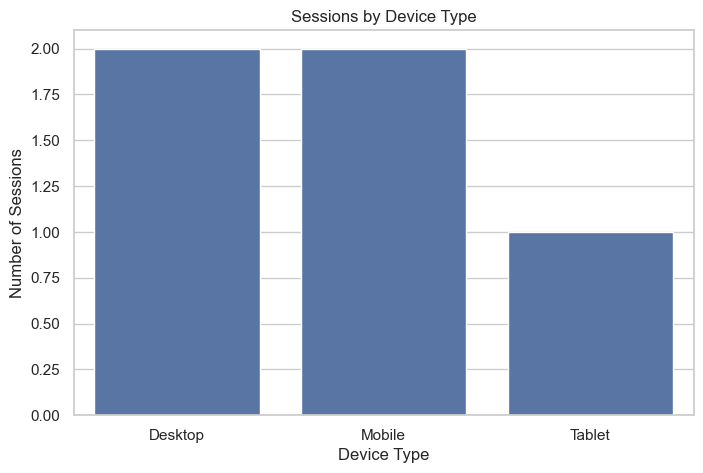

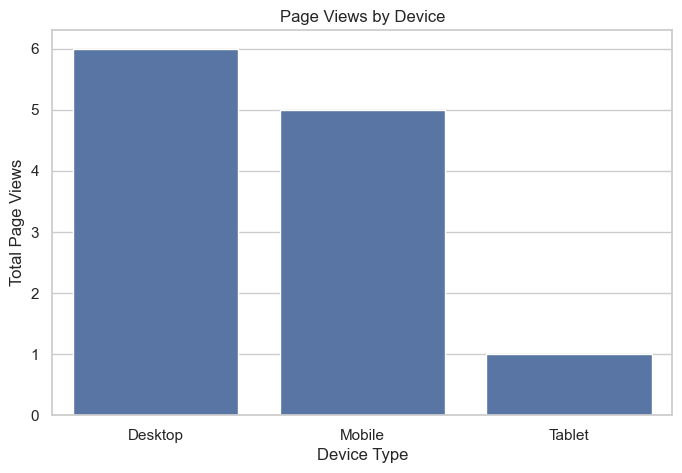

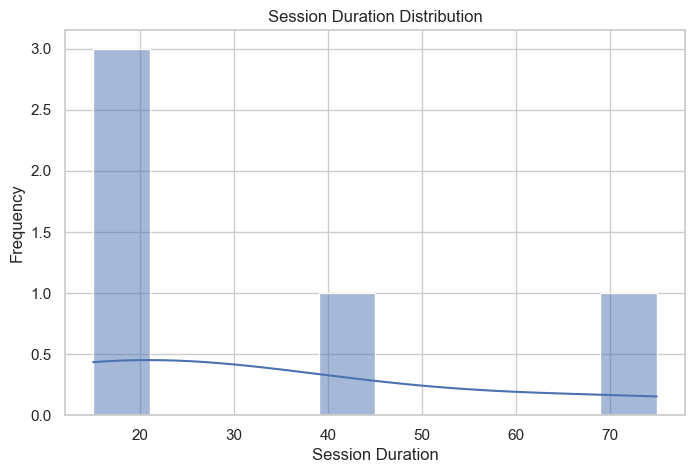

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample website logs data
data = {
    'session_id': [1,1,2,2,3,4,5,5],
    'page_views': [1,2,1,3,1,2,1,1],
    'duration': [30,45,-10,20,15,40,5,10],
    'device_type': ['Mobile','Mobile','Desktop','Desktop',
                    'Tablet','Mobile','Desktop','Desktop']
}

logs_df = pd.DataFrame(data)

# -----------------------------------
# Data Validation
# -----------------------------------

try:
    # Remove negative durations
    logs_df['duration'] = logs_df['duration'].clip(lower=0)

    # Remove missing values
    logs_df.dropna(inplace=True)

    # Ensure correct data types
    logs_df['session_id'] = logs_df['session_id'].astype(str)

except Exception as e:
    print(f"Validation Error: {e}")

# -----------------------------------
# Session-Level Calculations
# -----------------------------------

session_metrics = logs_df.groupby('session_id').agg({
    'page_views': 'sum',
    'duration': 'sum'
}).reset_index()

# Bounce Rate Calculation
# Bounce = sessions with exactly 1 page view

total_sessions = len(session_metrics)

bounce_sessions = len(
    session_metrics[session_metrics['page_views'] == 1]
)

bounce_rate = (bounce_sessions / total_sessions) * 100

# Average Session Time
avg_session_time = session_metrics['duration'].mean()

# Pages Per Session
pages_per_session = session_metrics['page_views'].mean()

metrics = {
    'bounce_rate': bounce_rate,
    'avg_session_time': avg_session_time,
    'pages_per_session': pages_per_session
}

print("Engagement Metrics")
print(metrics)

# -----------------------------------
# Device Metrics
# -----------------------------------

device_metrics = logs_df.groupby('device_type').agg({
    'session_id': 'nunique',
    'duration': 'mean',
    'page_views': 'sum'
}).reset_index()

print("\nDevice Metrics")
print(device_metrics)

# -----------------------------------
# Visualizations
# -----------------------------------

sns.set(style="whitegrid")

# Device Type Sessions
plt.figure(figsize=(8,5))
sns.barplot(
    x='device_type',
    y='session_id',
    data=device_metrics
)

plt.title('Sessions by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Number of Sessions')
plt.show()

# Page Views by Device
plt.figure(figsize=(8,5))
sns.barplot(
    x='device_type',
    y='page_views',
    data=device_metrics
)

plt.title('Page Views by Device')
plt.xlabel('Device Type')
plt.ylabel('Total Page Views')
plt.show()

# Session Duration Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    session_metrics['duration'],
    bins=10,
    kde=True
)

plt.title('Session Duration Distribution')
plt.xlabel('Session Duration')
plt.ylabel('Frequency')
plt.show()

## Follow-up Prompts

1. Explain why the original bounce rate logic was incorrect.
2. Add validation checks for unrealistic session durations.
3. Improve the visualization formatting for executive reporting.
4. Detect bot-like activity or abnormal sessions.
5. Add timestamp-based session calculations instead of raw duration fields.
6. Include logging and debugging messages for troubleshooting.

## Final Solution (Refined Version)

Website Engagement Metrics
{'bounce_rate (%)': 20.0, 'avg_session_time_seconds': np.float64(33.0), 'pages_per_session': np.float64(2.4)}

Device Metrics
  device_type  session_id   duration  page_views
0     Desktop           2   8.750000           6
1      Mobile           2  38.333333           5
2      Tablet           1  15.000000           1


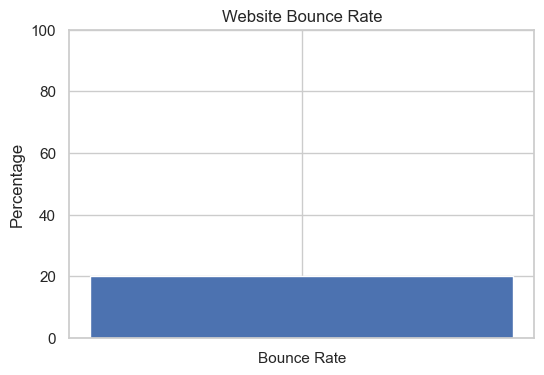

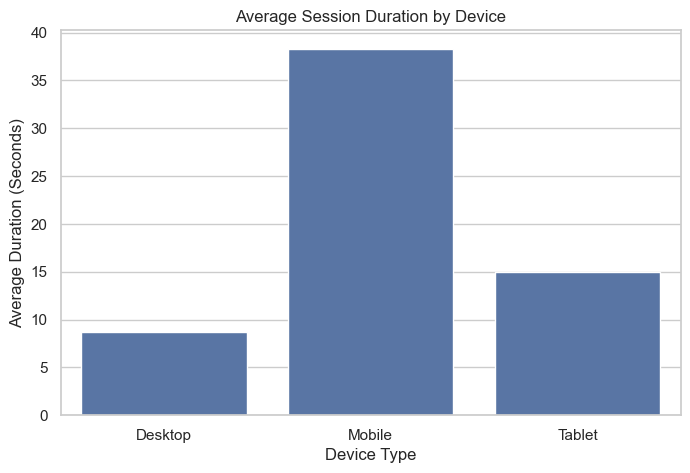

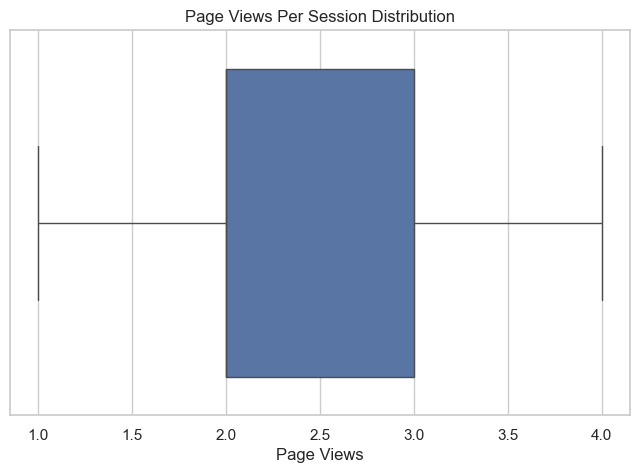

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# Sample Data
# -----------------------------------

data = {
    'session_id': [1,1,2,2,3,4,5,5],
    'page_views': [1,2,1,3,1,2,1,1],
    'duration': [30,45,-10,20,15,40,5,10],
    'device_type': ['Mobile','Mobile','Desktop','Desktop',
                    'Tablet','Mobile','Desktop','Desktop']
}

logs_df = pd.DataFrame(data)

# -----------------------------------
# Data Validation
# -----------------------------------

try:
    # Remove duplicate rows
    logs_df.drop_duplicates(inplace=True)

    # Handle missing values
    logs_df.dropna(inplace=True)

    # Convert durations to numeric
    logs_df['duration'] = pd.to_numeric(
        logs_df['duration'],
        errors='coerce'
    )

    # Replace invalid negative durations
    logs_df['duration'] = logs_df['duration'].clip(lower=0)

    # Remove unrealistic durations (> 8 hours)
    logs_df = logs_df[
        logs_df['duration'] <= 28800
    ]

except Exception as e:
    print(f"Data Validation Error: {e}")

# -----------------------------------
# Session Aggregation
# -----------------------------------

session_summary = logs_df.groupby('session_id').agg({
    'page_views': 'sum',
    'duration': 'sum'
}).reset_index()

# -----------------------------------
# Correct Bounce Rate
# -----------------------------------

total_sessions = session_summary.shape[0]

bounce_sessions = session_summary[
    session_summary['page_views'] == 1
].shape[0]

bounce_rate = round(
    (bounce_sessions / total_sessions) * 100,
    2
)

# -----------------------------------
# Other Metrics
# -----------------------------------

avg_session_time = round(
    session_summary['duration'].mean(),
    2
)

pages_per_session = round(
    session_summary['page_views'].mean(),
    2
)

metrics = {
    'bounce_rate (%)': bounce_rate,
    'avg_session_time_seconds': avg_session_time,
    'pages_per_session': pages_per_session
}

print("Website Engagement Metrics")
print(metrics)

# -----------------------------------
# Device Analysis
# -----------------------------------

device_metrics = logs_df.groupby('device_type').agg({
    'session_id': 'nunique',
    'duration': 'mean',
    'page_views': 'sum'
}).reset_index()

print("\nDevice Metrics")
print(device_metrics)

# -----------------------------------
# Visualizations
# -----------------------------------

sns.set(style="whitegrid")

# Bounce Rate Visualization
plt.figure(figsize=(6,4))
plt.bar(
    ['Bounce Rate'],
    [bounce_rate]
)

plt.title('Website Bounce Rate')
plt.ylabel('Percentage')
plt.ylim(0, 100)
plt.show()

# Session Duration by Device
plt.figure(figsize=(8,5))
sns.barplot(
    x='device_type',
    y='duration',
    data=device_metrics
)

plt.title('Average Session Duration by Device')
plt.xlabel('Device Type')
plt.ylabel('Average Duration (Seconds)')
plt.show()

# Page Views Distribution
plt.figure(figsize=(8,5))
sns.boxplot(
    x=session_summary['page_views']
)

plt.title('Page Views Per Session Distribution')
plt.xlabel('Page Views')
plt.show()

## Discussion Questions

1. How did different prompts approach error identification?

Different prompts identified errors with varying levels of depth. Basic prompts only corrected syntax or calculation issues, while more advanced prompts analyzed business logic problems such as incorrect bounce rate formulas and unrealistic session durations. Detailed prompts encouraged the AI to explain why the errors occurred and suggest preventive validation techniques.

2. What validation methods were suggested?

The AI suggested several validation methods including:

Removing duplicate rows
Handling missing values with dropna()
Converting fields to numeric types
Preventing negative durations using .clip(lower=0)
Filtering unrealistic session times
Using datatype validation and error coercion

These checks improved data reliability and prevented invalid calculations.

3. How was time handling improved?

Time handling was improved by:

Converting duration values into numeric format
Removing negative session times
Filtering unrealistic durations
Aggregating total session duration correctly by session_id
Suggesting timestamp-based calculations for more accurate session tracking

More refined prompts produced cleaner and more realistic engagement metrics suitable for business reporting.